## The Green Transition: Quantifying Predictability and Power Shifts from Legacy to GenAI Workloads

In [ ]:
# Install required packages
!pip install pgmpy networkx matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import os
import tarfile
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import networkx as nx

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from pgmpy.causal_discovery import HillClimbSearch

# Suppress warnings for clean output
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
def load_and_prep_data(n_samples=5000):
    """
    Downloads and prepares actual Alibaba Cluster Trace data.
    If n_samples is None, it attempts to load the entire dataset (Requires High-RAM Colab).
    """
    print(f"Initializing Data Ingestion pipeline... (Targeting {n_samples if n_samples else 'ALL'} samples)")

    # Calculate nrows for reading chunks (if n_samples is specified)
    # We read 50x the target sample size to account for data loss during grouping/filtering
    read_limit = (n_samples * 50) if n_samples else None

    # ==========================================
    # DATASET 1: ALIBABA 2018 (LEGACY MIXED)
    # ==========================================
    url_2018 = "http://aliopentrace.oss-cn-beijing.aliyuncs.com/v2018Traces/machine_usage.tar.gz"

    if not os.path.exists('machine_usage.csv'):
        print("Downloading 2018 Machine Usage (approx 1.7GB)...")
        os.system(f"wget -q -O machine_usage.tar.gz {url_2018}")
        print("Extracting 2018 data...")
        with tarfile.open("machine_usage.tar.gz", "r:gz") as tar:
            tar.extractall()

    print("Processing 2018 Legacy Traces...")
    cols_2018 = ['machine_id', 'time_stamp', 'cpu_util_percent', 'mem_util_percent',
                 'mem_gps', 'mkpi', 'net_in', 'net_out', 'disk_io_percent']

    df_2018_raw = pd.read_csv('machine_usage.csv', names=cols_2018, nrows=read_limit, on_bad_lines='skip')

    # Clean invalid metrics
    df_2018_raw = df_2018_raw[(df_2018_raw['cpu_util_percent'] >= 0) & (df_2018_raw['cpu_util_percent'] <= 100)]
    df_2018_raw = df_2018_raw[(df_2018_raw['disk_io_percent'] >= 0) & (df_2018_raw['disk_io_percent'] <= 100)]

    # Aggregate to cluster-wide average
    df_2018 = df_2018_raw.groupby('time_stamp').agg({
        'cpu_util_percent': 'mean',
        'mem_util_percent': 'mean',
        'disk_io_percent': 'mean'
    }).reset_index()

    if n_samples: df_2018 = df_2018.iloc[:n_samples]

    # Power Proxy 2018: CPU is the primary driver
    df_2018['estimated_power'] = (df_2018['cpu_util_percent'] * 0.7) + (df_2018['mem_util_percent'] * 0.2) + (df_2018['disk_io_percent'] * 0.1)
    df_2018['timestamp'] = pd.to_datetime(df_2018['time_stamp'], unit='s')

    # ==========================================
    # DATASET 2: ALIBABA 2026 (GEN-AI)
    # ==========================================
    url_2026_gpu = "https://github.com/alibaba/clusterdata/raw/master/cluster-trace-v2026-GenAI/pod_gpu_duty_cycle_anon.tar.gz"
    url_2026_mem = "https://github.com/alibaba/clusterdata/raw/master/cluster-trace-v2026-GenAI/pod_memory_util_anon.tar.gz"

    if not os.path.exists('pod_gpu_duty_cycle_anon.csv'):
        print("Downloading 2026 GenAI GPU & Memory Usage...")
        os.system(f"wget -q -O gpu_usage.tar.gz {url_2026_gpu}")
        os.system(f"wget -q -O mem_usage.tar.gz {url_2026_mem}")

        print("Extracting 2026 data...")
        with tarfile.open("gpu_usage.tar.gz", "r:gz") as tar: tar.extractall()
        with tarfile.open("mem_usage.tar.gz", "r:gz") as tar: tar.extractall()

    print("Processing 2026 GenAI Traces...")
    cols_2026 = ['value', 'timestamp_anon', 'container_ip']

    df_2026_gpu = pd.read_csv('pod_gpu_duty_cycle_anon.csv', names=cols_2026, nrows=read_limit, on_bad_lines='skip')
    df_2026_mem = pd.read_csv('pod_memory_util_anon.csv', names=cols_2026, nrows=read_limit, on_bad_lines='skip')

    df_2026_gpu.rename(columns={'value': 'gpu_util'}, inplace=True)
    df_2026_mem.rename(columns={'value': 'mem_util'}, inplace=True)

    # Convert to numeric, coercing errors to NaN, then drop NaNs
    df_2026_gpu['gpu_util'] = pd.to_numeric(df_2026_gpu['gpu_util'], errors='coerce',downcast='float').astype(float)
    df_2026_mem['mem_util'] = pd.to_numeric(df_2026_mem['mem_util'], errors='coerce',downcast='float').astype(float)
    df_2026_gpu.dropna(subset=['gpu_util'], inplace=True)
    df_2026_mem.dropna(subset=['mem_util'], inplace=True)

    print(df_2026_gpu.count())
    print(df_2026_mem.count())

    df_2026_gpu = df_2026_gpu[(df_2026_gpu['gpu_util'] > 0) & (df_2026_gpu['gpu_util'] <= 100)]
    df_2026_mem = df_2026_mem[(df_2026_mem['mem_util'] > 0) & (df_2026_mem['mem_util'] <= 100)]

    print("Merging 2026 Pod Resources on Timestamp and IP...")
    df_2026_raw = pd.merge(df_2026_gpu, df_2026_mem, on=['timestamp_anon', 'container_ip'], how='inner')

    df_2026 = df_2026_raw.groupby('timestamp_anon').agg({
        'gpu_util': 'mean',
        'mem_util': 'mean'
    }).reset_index()


    if n_samples: df_2026 = df_2026.iloc[:n_samples]

    # Power Proxy 2026: GPU is the primary driver
    df_2026['estimated_power'] = (df_2026['gpu_util'] * 0.7) + (df_2026['mem_util'] * 0.3)
    df_2026['timestamp'] = pd.to_datetime(df_2026['timestamp_anon'], unit='s')

    print("Data preparation complete!\n")
    return df_2018, df_2026

# Set to None for complete dataset, or an integer for faster testing
SAMPLE_SIZE = None
df_2018, df_2026 = load_and_prep_data()

print(f"2018 Baseline Ready: {df_2018.shape[0]} timestamps.")
print(f"2026 GenAI Ready: {df_2026.shape[0]} timestamps.")

Initializing Data Ingestion pipeline... (Targeting 5000 samples)
Extracting 2018 data...
Processing 2018 Legacy Traces...
Extracting 2026 data...
Processing 2026 GenAI Traces...
gpu_util          157417
timestamp_anon    157417
container_ip      157417
dtype: int64
mem_util          214890
timestamp_anon    214890
container_ip      214841
dtype: int64
Merging 2026 Pod Resources on Timestamp and IP...
Data preparation complete!

2018 Baseline Ready: 5000 timestamps.
2026 GenAI Ready: 1335 timestamps.


In [ ]:
def plot_psf_timeseries(df_2018, df_2026):
    """
    Adjusts the timestamps to match the actual eras (2018 and 2026)
    and generates the comparative Time Series Plot for the Power-Scaling Factor.
    """

    # ---------------------------------------------------------
    # 1. Timestamp Alignment (Shifting from Epoch to Target Year)
    # ---------------------------------------------------------

    # Ensure raw timestamps are datetime objects
    if not np.issubdtype(df_2018['timestamp'].dtype, np.datetime64):
        df_2018['timestamp'] = pd.to_datetime(df_2018['timestamp'])
    if not np.issubdtype(df_2026['timestamp'].dtype, np.datetime64):
        df_2026['timestamp'] = pd.to_datetime(df_2026['timestamp'])

    # Shift 2018 data to start exactly at 2018-01-01
    offset_18 = pd.to_datetime('2018-01-01') - df_2018['timestamp'].min()
    df_2018['timestamp_adj'] = df_2018['timestamp'] + offset_18

    # Shift 2026 data to start exactly at 2026-01-01
    offset_26 = pd.to_datetime('2026-01-01') - df_2026['timestamp'].min()
    df_2026['timestamp_adj'] = df_2026['timestamp'] + offset_26

    # ---------------------------------------------------------
    # 2. Plotting Figure 1
    # ---------------------------------------------------------

    # Create a 2-row subplot sharing the same Y-axis range to emphasize magnitude differences
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharey=True)

    # Subplot A: 2018 Legacy Mixed Workloads
    axes[0].plot(df_2018['timestamp_adj'], df_2018['estimated_power'],
                 color='#3498db', linewidth=1.2, alpha=0.9)
    axes[0].set_title('Figure 1A: Legacy Mixed Workloads (2018) - Power-Scaling Factor',
                      fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Power Proxy (Normalized)')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Subplot B: 2026 GenAI Workloads
    axes[1].plot(df_2026['timestamp_adj'], df_2026['estimated_power'],
                 color='#e74c3c', linewidth=1.2, alpha=0.9)
    axes[1].set_title('Figure 1B: GenAI GPU/HBM Workloads (2026) - Power-Scaling Factor',
                      fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Power Proxy (Normalized)')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # ---------------------------------------------------------
    # 3. Axis Formatting
    # ---------------------------------------------------------

    # Format the X-axis to cleanly display the adjusted dates
    date_format = mdates.DateFormatter('%Y-%m-%d %H:%M')

    for ax in axes:
        ax.xaxis.set_major_formatter(date_format)
        # Rotate labels so they don't overlap
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')

        # Emphasize the strict physical limit of power capping
        cap_limit = max(df_2018['estimated_power'].max(), df_2026['estimated_power'].max()) * 0.85
        ax.axhline(cap_limit, color='green', linestyle=':', linewidth=2,
                   label='Hypothetical Facility Power Cap')
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Execute the visualization (assuming df_2018 and df_2026 are already loaded in Colab)
# plot_psf_timeseries(df_2018, df_2026)

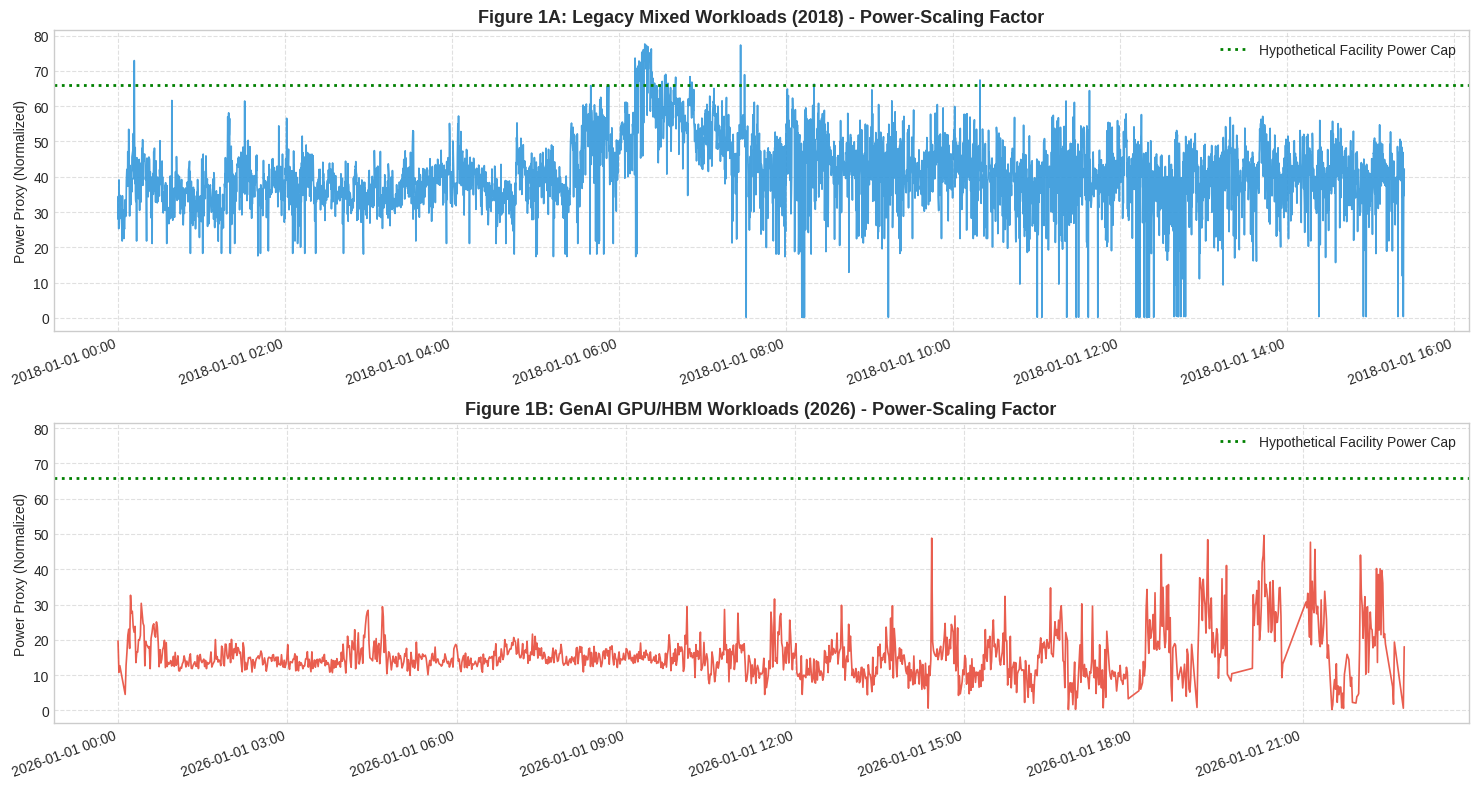

In [ ]:
plot_psf_timeseries(df_2018, df_2026)

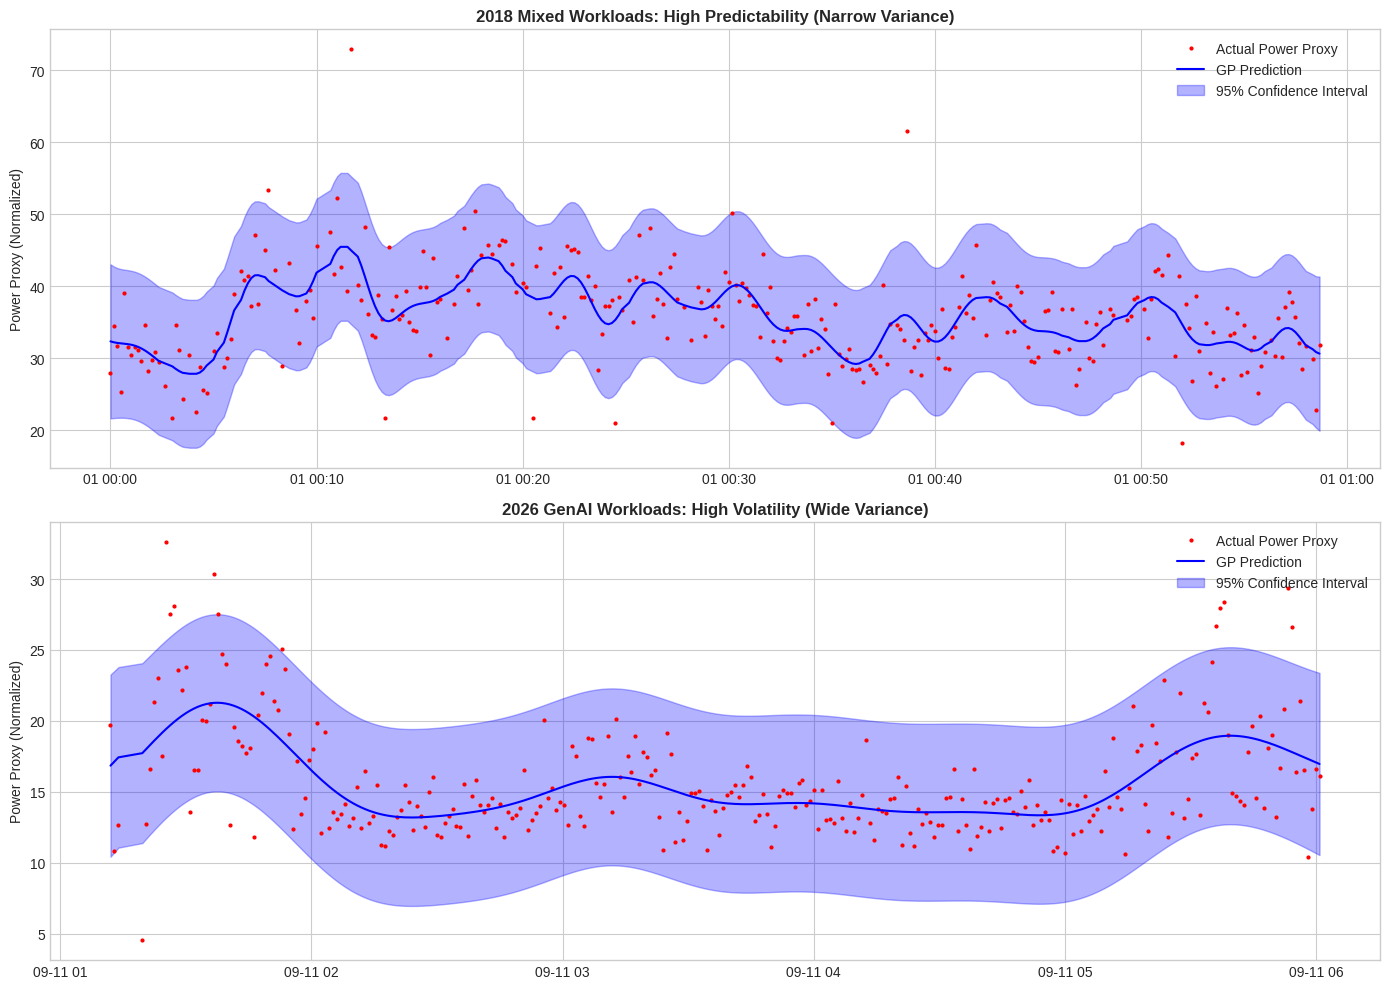

Mean GP Uncertainty 2018: 5.238
Mean GP Uncertainty 2026: 3.185
Predictability Degradation: -39.19% increase in predictive uncertainty.


In [ ]:
def plot_gp_predictability(df, title, ax):
    # GP is O(N^3). Limit fitting to 300 points for Colab runtime safety.
    df_sample = df.iloc[:300].copy() if len(df) > 300 else df.copy()

    X = np.arange(len(df_sample)).reshape(-1, 1)
    y = df_sample['estimated_power'].values

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    X_scaled = scaler_x.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

    kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)

    gp.fit(X_scaled, y_scaled)
    y_pred, sigma = gp.predict(X_scaled, return_std=True)

    y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    sigma_orig = sigma * scaler_y.scale_[0]

    ax.plot(df_sample['timestamp'], y, 'r.', markersize=4, label='Actual Power Proxy')
    ax.plot(df_sample['timestamp'], y_pred_orig, 'b-', label='GP Prediction')
    ax.fill_between(df_sample['timestamp'],
                    y_pred_orig - 1.96 * sigma_orig,
                    y_pred_orig + 1.96 * sigma_orig,
                    alpha=0.3, color='blue', label='95% Confidence Interval')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel("Power Proxy (Normalized)")
    ax.legend(loc='upper right')

    return np.mean(sigma_orig)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
sigma_2018 = plot_gp_predictability(df_2018, "2018 Mixed Workloads: High Predictability (Narrow Variance)", axes[0])
sigma_2026 = plot_gp_predictability(df_2026, "2026 GenAI Workloads: High Volatility (Wide Variance)", axes[1])
plt.tight_layout()
plt.show()

print(f"Mean GP Uncertainty 2018: {sigma_2018:.3f}")
print(f"Mean GP Uncertainty 2026: {sigma_2026:.3f}")
if sigma_2018 > 0:
    print(f"Predictability Degradation: {((sigma_2026 - sigma_2018)/sigma_2018)*100:.2f}% increase in predictive uncertainty.")

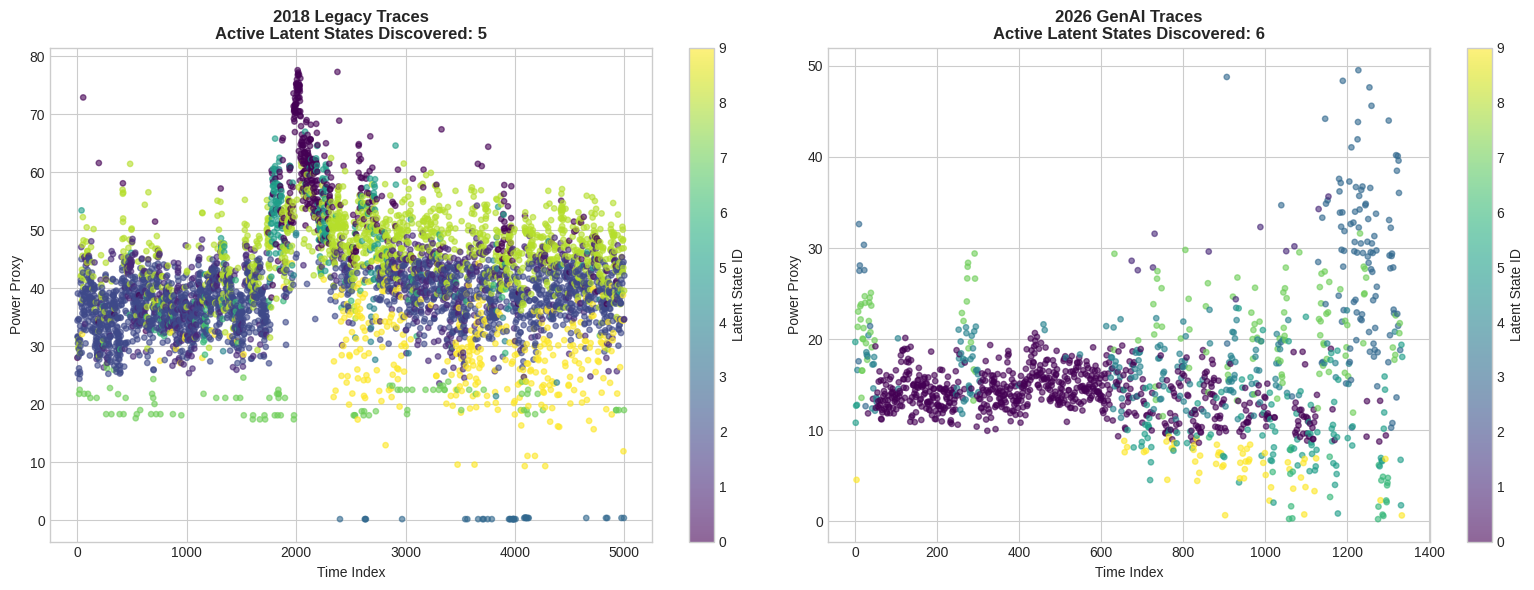

In [ ]:
def discover_latent_states(df, features, title, ax):
    X = df[features].dropna().values
    if len(X) == 0:
        ax.set_title(f"{title} - No Data")
        return

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # DPMM infers the number of required clusters automatically
    dpmm = BayesianGaussianMixture(n_components=10, weight_concentration_prior=0.1, max_iter=500, random_state=42)
    labels = dpmm.fit_predict(X_scaled)

    active_components = np.sum(dpmm.weights_ > 0.05)

    # Align indices for plotting
    plot_x = df.dropna(subset=features).index
    plot_y = df.dropna(subset=features)['estimated_power']

    scatter = ax.scatter(plot_x, plot_y, c=labels, cmap='viridis', alpha=0.6, s=15)
    ax.set_title(f"{title}\nActive Latent States Discovered: {active_components}", fontweight='bold')
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Power Proxy")
    plt.colorbar(scatter, ax=ax, label='Latent State ID')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
discover_latent_states(df_2018, ['cpu_util_percent', 'mem_util_percent', 'disk_io_percent'], "2018 Legacy Traces", axes[0])
discover_latent_states(df_2026, ['gpu_util', 'mem_util'], "2026 GenAI Traces", axes[1])
plt.tight_layout()
plt.show()

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

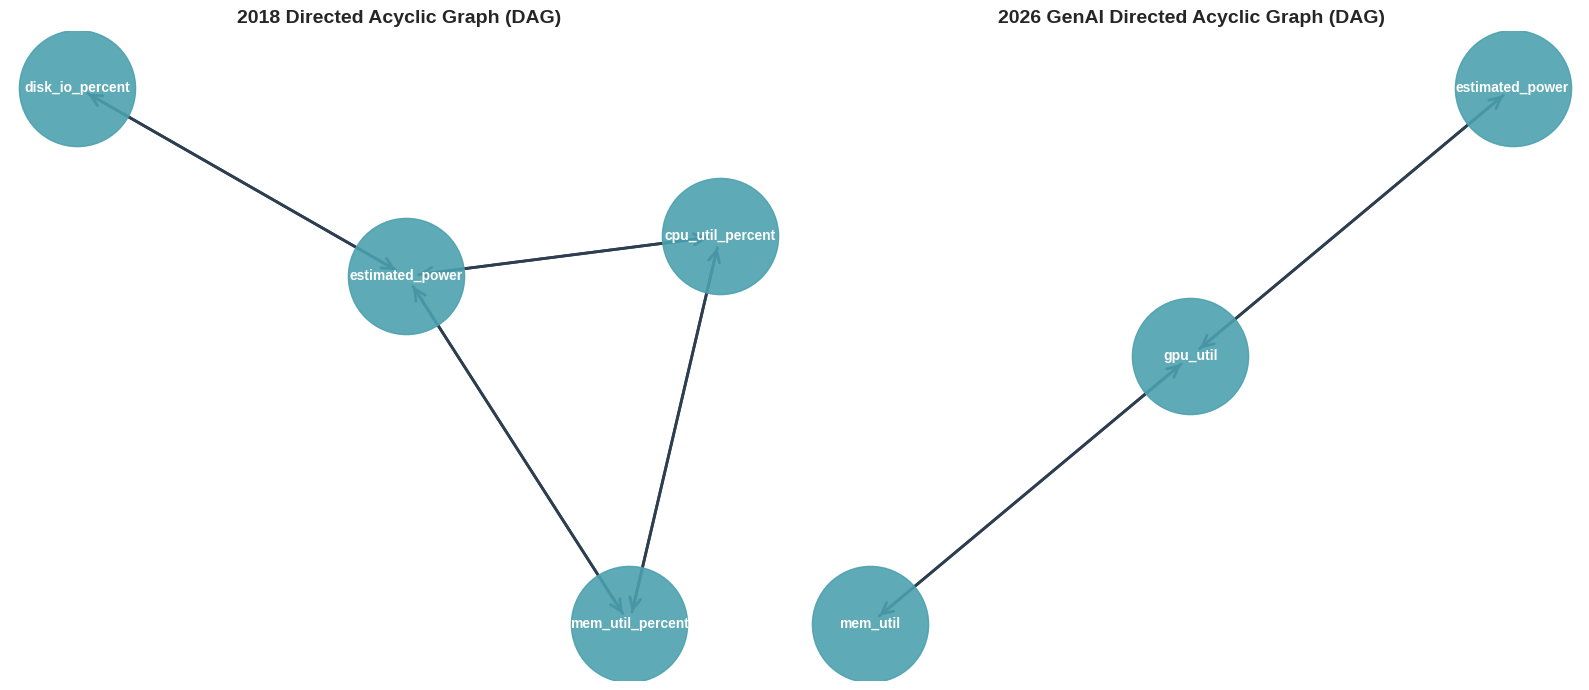

In [ ]:
def learn_and_plot_causal_graph(df, features, title, ax):
    df_disc = df[features].dropna().copy()

    # Discretize continuous values into bins for BN Structure Learning
    for col in features:
        df_disc[col] = pd.qcut(df_disc[col], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

    # Structure learning using Hill Climb Search optimized via BIC
    hc = HillClimbSearch(scoring_method="bic-d")
    best_model = hc.fit(df_disc)

    G = nx.DiGraph()
    G.add_edges_from(best_model.causal_graph_.edges())

    pos = nx.spring_layout(G, seed=42)

    # Visual Styling
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=7000, node_color='#4CA1AF', alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight='bold', font_color='white')
    nx.draw_networkx_edges(G, pos, ax=ax, width=2, arrowsize=20, edge_color='#2C3E50', arrowstyle='->')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
learn_and_plot_causal_graph(df_2018, ['cpu_util_percent', 'mem_util_percent', 'disk_io_percent', 'estimated_power'],
                            "2018 Directed Acyclic Graph (DAG)", axes[0])
learn_and_plot_causal_graph(df_2026, ['gpu_util', 'mem_util', 'estimated_power'],
                            "2026 GenAI Directed Acyclic Graph (DAG)", axes[1])
plt.tight_layout()
plt.show()